Criando dataframe

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

df = iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Adequando dataset

Renomeando as colunas

In [ ]:
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "target"
]

Convertendo o target de númerico para o nome da espécie

In [ ]:
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df = df.drop(columns="target")

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


### Informações:

In [ ]:
df.shape

(150, 5)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Valores ausentes

In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


O dataset não apresenta valores ausentes, portanto não foi necessário aplicar técnicas de preenchimento ou remoção de registros.

### Registros duplicados

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica


Foram encontrados registros com medidas repetidas. Como o dataset representa observações reais de flores, esses registros não foram removidos, pois podem corresponder a indivíduos diferentes com características semelhantes.

### Estatisticas pos espécies

In [ ]:
df.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
df.groupby("species").agg(
    ["mean", "median", "std", "min", "max"]
)

sepal_length                            sepal_width         \
                   mean median       std  min  max        mean median   
species                                                                 
setosa            5.006    5.0  0.352490  4.3  5.8       3.428    3.4   
versicolor        5.936    5.9  0.516171  4.9  7.0       2.770    2.8   
virginica         6.588    6.5  0.635880  4.9  7.9       2.974    3.0   

                               petal_length                             \
                 std  min  max         mean median       std  min  max   
species                                                                  
setosa      0.379064  2.3  4.4        1.462   1.50  0.173664  1.0  1.9   
versicolor  0.313798  2.0  3.4        4.260   4.35  0.469911  3.0  5.1   
virginica   0.322497  2.2  3.8        5.552   5.55  0.551895  4.5  6.9   

           petal_width                             
                  mean median       std  min  max  
species                                            
setosa           0.246    0.2  0.105386  0.1  0.6  
versicolor       1.326    1.3  0.197753  1.0  1.8  
virginica        2.026    2.0  0.274650  1.4  2.5

In [ ]:
species_summary = df.groupby("species").agg({
    "sepal_length": ["mean", "median", "std"],
    "sepal_width": ["mean", "median", "std"],
    "petal_length": ["mean", "median", "std"],
    "petal_width": ["mean", "median", "std"]
})

species_summary

sepal_length                  sepal_width                   \
                   mean median       std        mean median       std   
species                                                                 
setosa            5.006    5.0  0.352490       3.428    3.4  0.379064   
versicolor        5.936    5.9  0.516171       2.770    2.8  0.313798   
virginica         6.588    6.5  0.635880       2.974    3.0  0.322497   

           petal_length                  petal_width                   
                   mean median       std        mean median       std  
species                                                                
setosa            1.462   1.50  0.173664       0.246    0.2  0.105386  
versicolor        4.260   4.35  0.469911       1.326    1.3  0.197753  
virginica         5.552   5.55  0.551895       2.026    2.0  0.274650

### Distribuição das espécies

In [ ]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
df["species"].value_counts(normalize=True) * 100

,proportion
species,
setosa,33.333333
versicolor,33.333333
virginica,33.333333


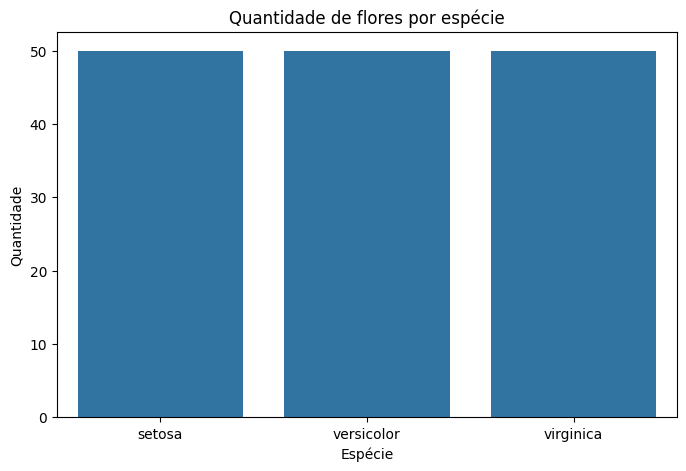

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Quantidade de flores por espécie")
plt.xlabel("Espécie")
plt.ylabel("Quantidade")
plt.show()

O dataset está balanceado.

## Análise univariada

### Histogramas

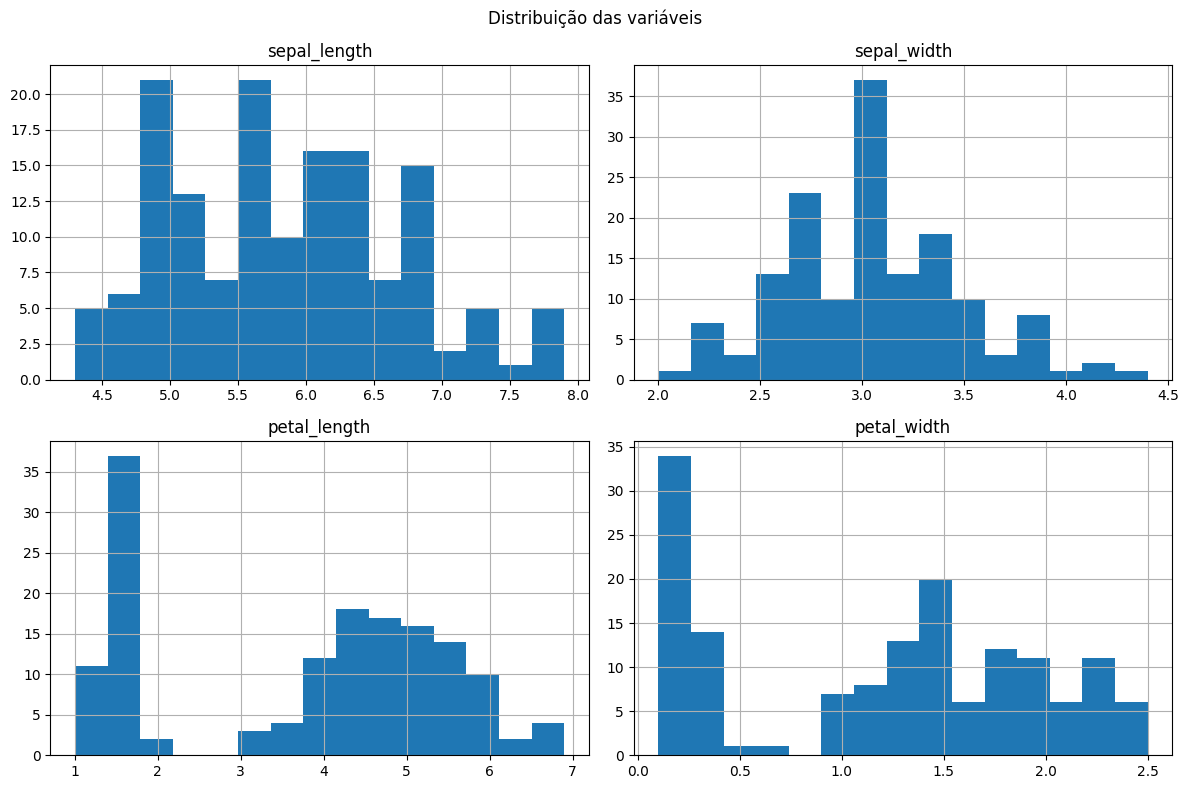

In [ ]:
numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Distribuição das variáveis")
plt.tight_layout()
plt.show()

### Por espécies

Pétala

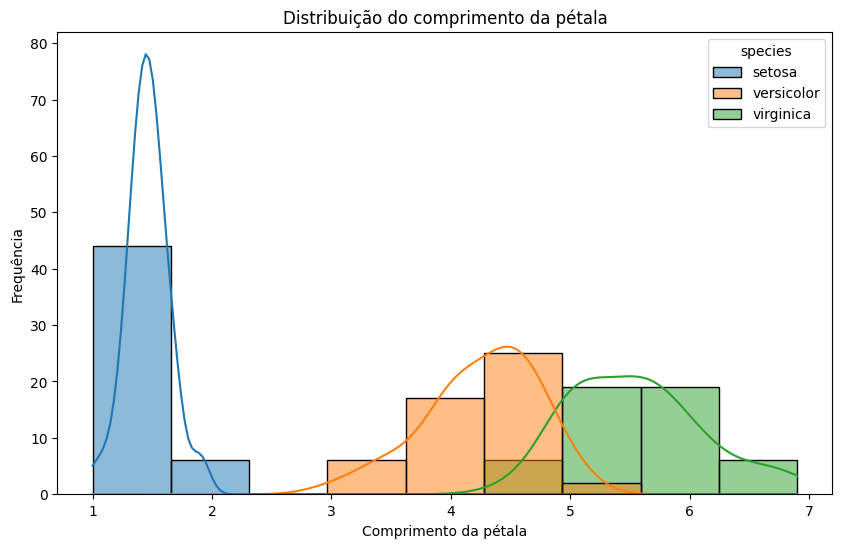

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="petal_length",
    hue="species",
    kde=True,
    multiple="layer"
)

plt.title("Distribuição do comprimento da pétala")
plt.xlabel("Comprimento da pétala")
plt.ylabel("Frequência")
plt.show()

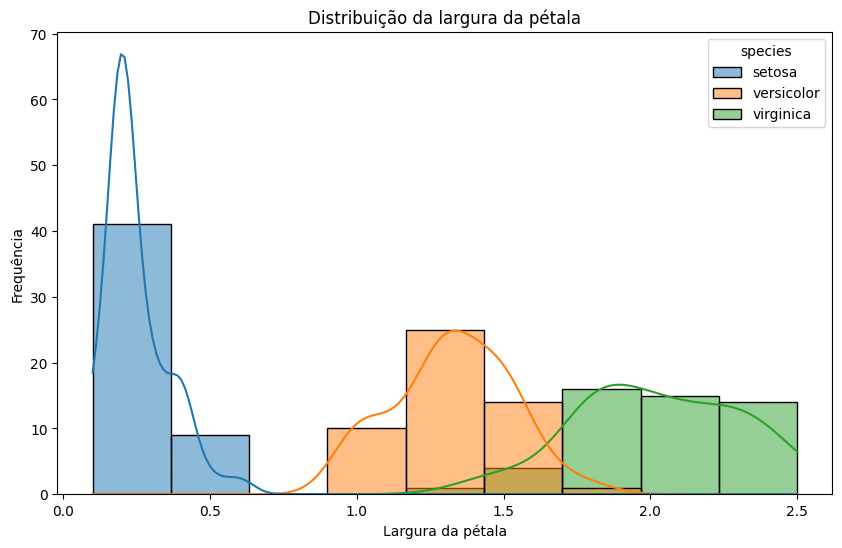

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="petal_width",
    hue="species",
    kde=True,
    multiple="layer"
)

plt.title("Distribuição da largura da pétala")
plt.xlabel("Largura da pétala")
plt.ylabel("Frequência")
plt.show()

Sépala

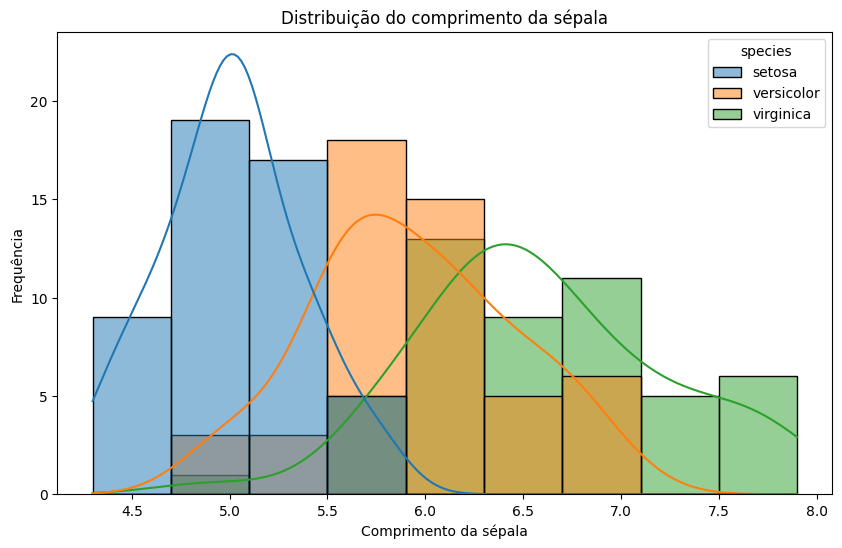

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="sepal_length",
    hue="species",
    kde=True,
    multiple="layer"
)

plt.title("Distribuição do comprimento da sépala")
plt.xlabel("Comprimento da sépala")
plt.ylabel("Frequência")
plt.show()

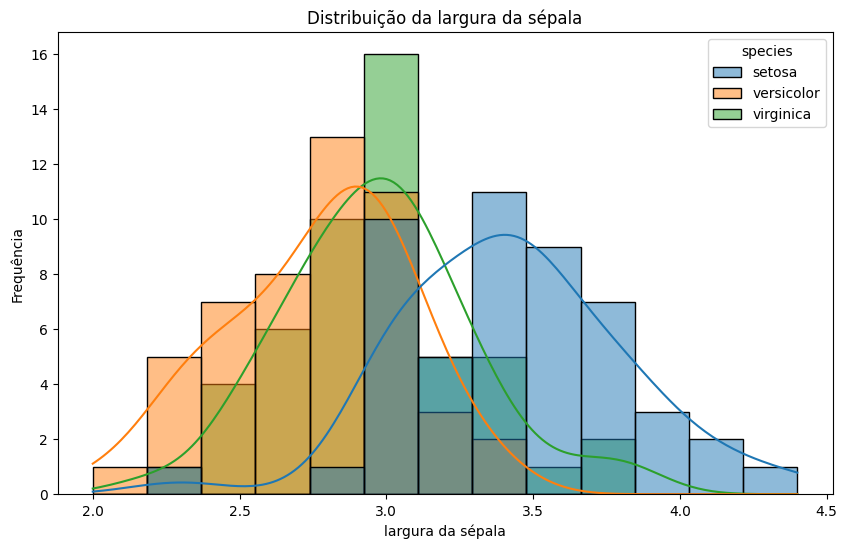

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="sepal_width",
    hue="species",
    kde=True,
    multiple="layer"
)

plt.title("Distribuição da largura da sépala")
plt.xlabel("largura da sépala")
plt.ylabel("Frequência")
plt.show()

## Boxplots

Pétala

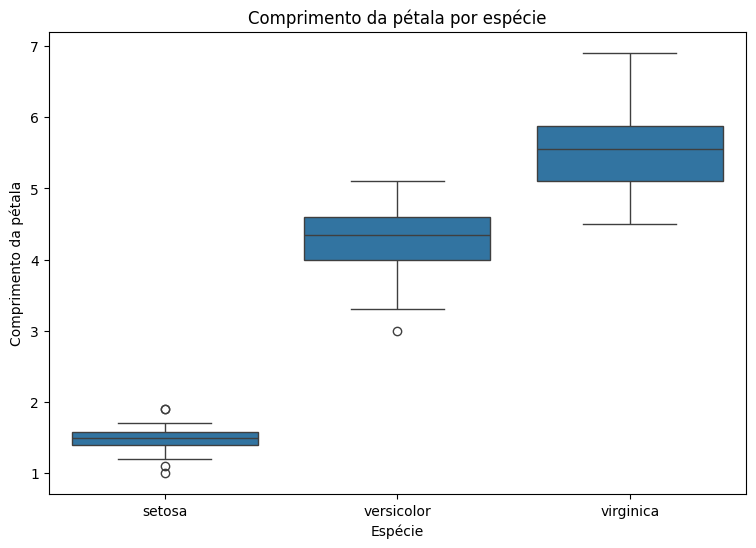

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="species",
    y="petal_length"
)

plt.title("Comprimento da pétala por espécie")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da pétala")
plt.show()

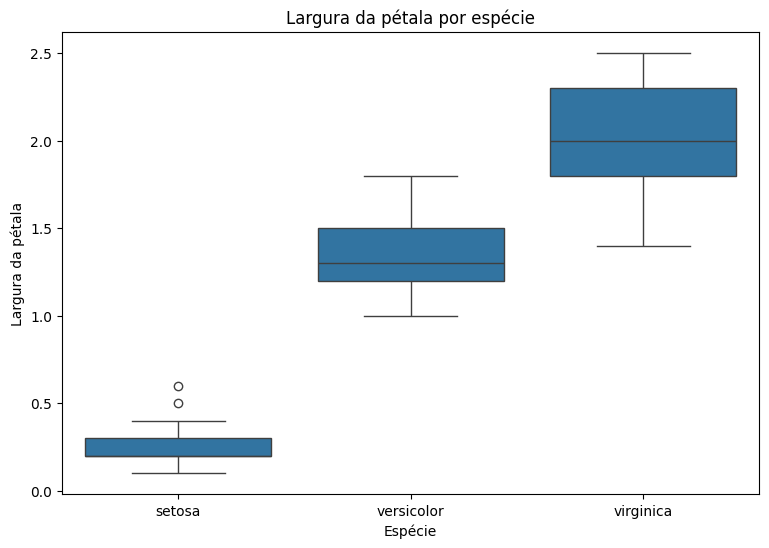

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="species",
    y="petal_width"
)

plt.title("Largura da pétala por espécie")
plt.xlabel("Espécie")
plt.ylabel("Largura da pétala")
plt.show()

Sépala

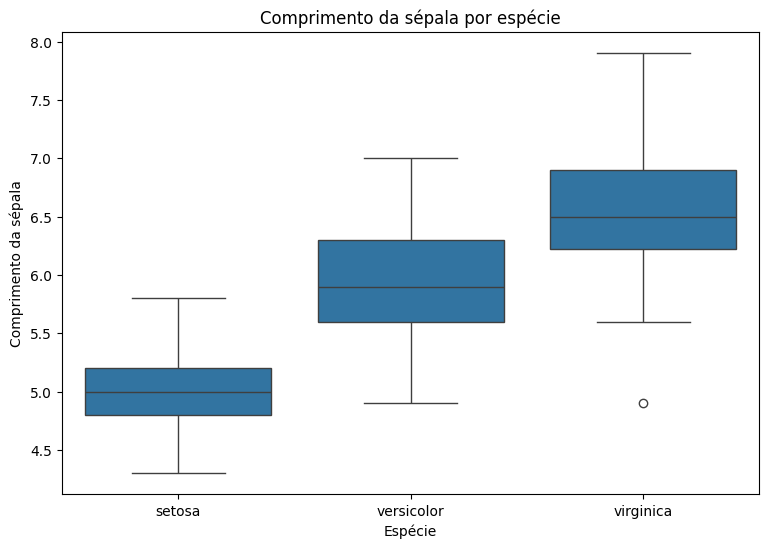

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="species",
    y="sepal_length"
)

plt.title("Comprimento da sépala por espécie")
plt.xlabel("Espécie")
plt.ylabel("Comprimento da sépala")
plt.show()

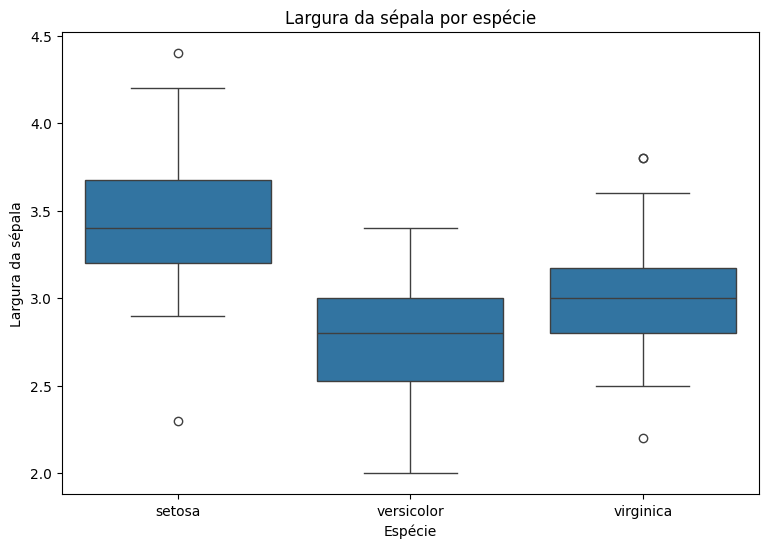

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="species",
    y="sepal_width"
)

plt.title("Largura da sépala por espécie")
plt.xlabel("Espécie")
plt.ylabel("Largura da sépala")
plt.show()

Visualização

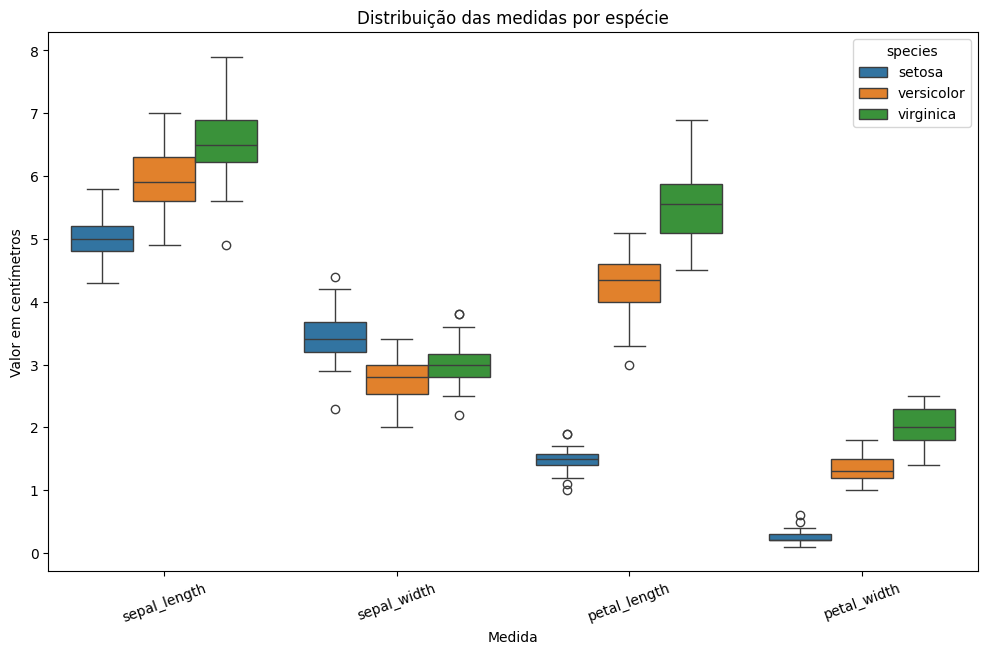

In [ ]:
df_long = df.melt(
    id_vars="species",
    var_name="measurement",
    value_name="value"
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_long,
    x="measurement",
    y="value",
    hue="species"
)

plt.title("Distribuição das medidas por espécie")
plt.xlabel("Medida")
plt.ylabel("Valor em centímetros")
plt.xticks(rotation=20)
plt.show()

## Análise de correlação

matriz

In [ ]:
numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

correlation = df[numeric_columns].corr()

correlation

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


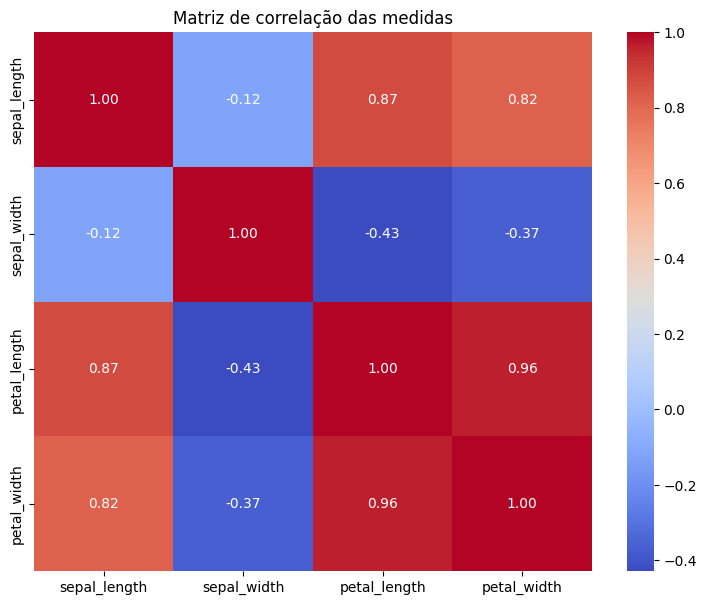

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de correlação das medidas")
plt.show()

## Gráficos

### Gráfico de dispersão

Pétala

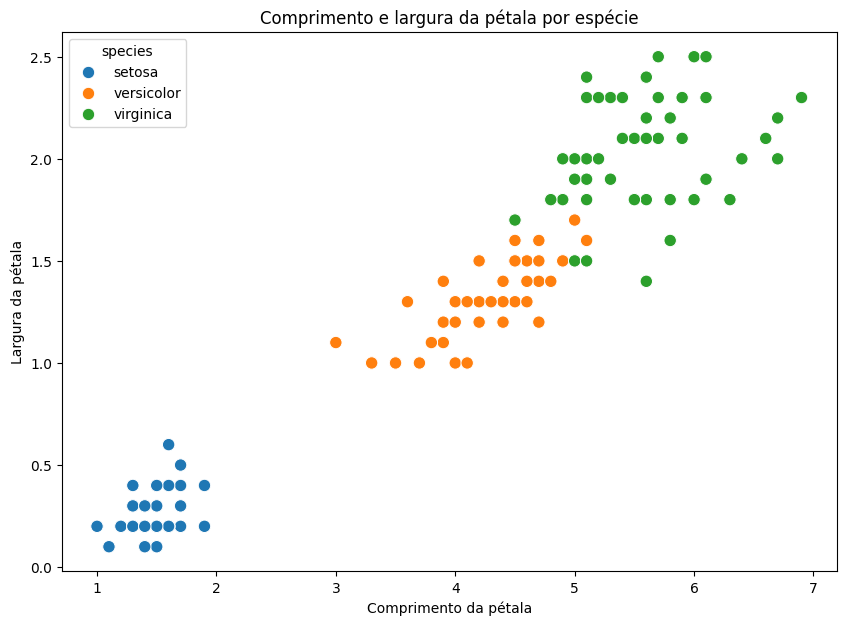

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=80
)

plt.title("Comprimento e largura da pétala por espécie")
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.show()

Sepala

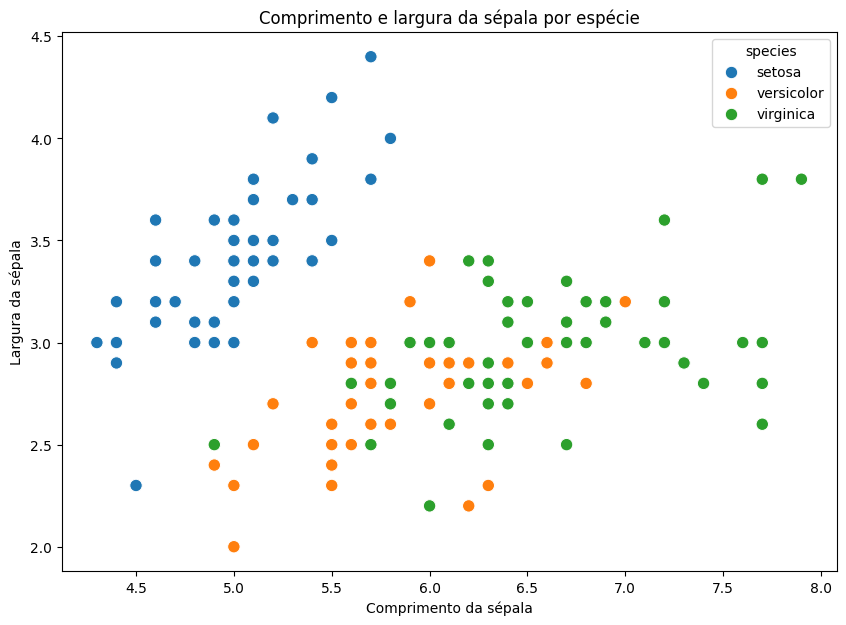

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species",
    s=80
)

plt.title("Comprimento e largura da sépala por espécie")
plt.xlabel("Comprimento da sépala")
plt.ylabel("Largura da sépala")
plt.show()

As variáveis relacionadas às pétalas apresentam maior capacidade de separação visual entre as espécies. A espécie Setosa forma um grupo claramente distinto, enquanto Versicolor e Virginica apresentam alguma sobreposição.

### Gráfico de Pares

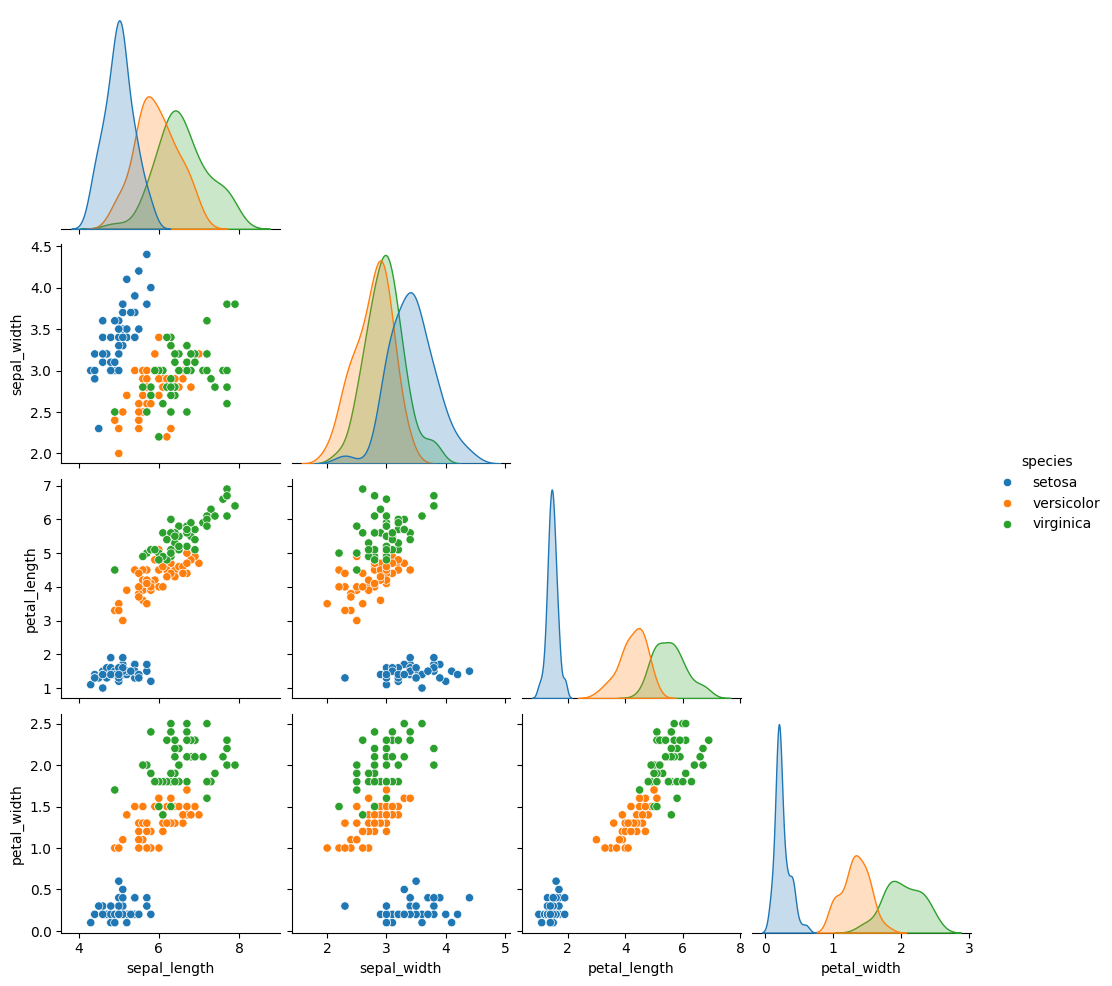

In [ ]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="kde",
    corner=True
)

plt.show()

### Interativos

In [31]:
fig = px.box(
    df,
    x="species",
    y="petal_length",
    color="species",
    title="Comprimento da pétala por espécie"
)

fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="petal_length",
    y="petal_width",
    color="species",
    hover_data=[
        "sepal_length",
        "sepal_width"
    ],
    title="Relação entre comprimento e largura da pétala"
)

fig.show()

In [32]:
fig = px.scatter_matrix(
    df,
    dimensions=numeric_columns,
    color="species",
    title="Matriz interativa de dispersão"
)

fig.show()

## Possíveis outliers

In [ ]:
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f"{column}: {len(outliers)} possíveis outliers")

sepal_length: 0 possíveis outliers
sepal_width: 4 possíveis outliers
petal_length: 0 possíveis outliers
petal_width: 0 possíveis outliers


Valores extremos foram tratados apenas como observações que merecem investigação. Como o dataset é pequeno e bem documentado, eles não foram removidos.

## PCA

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[numeric_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    components,
    columns=["PC1", "PC2"]
)

pca_df["species"] = df["species"]

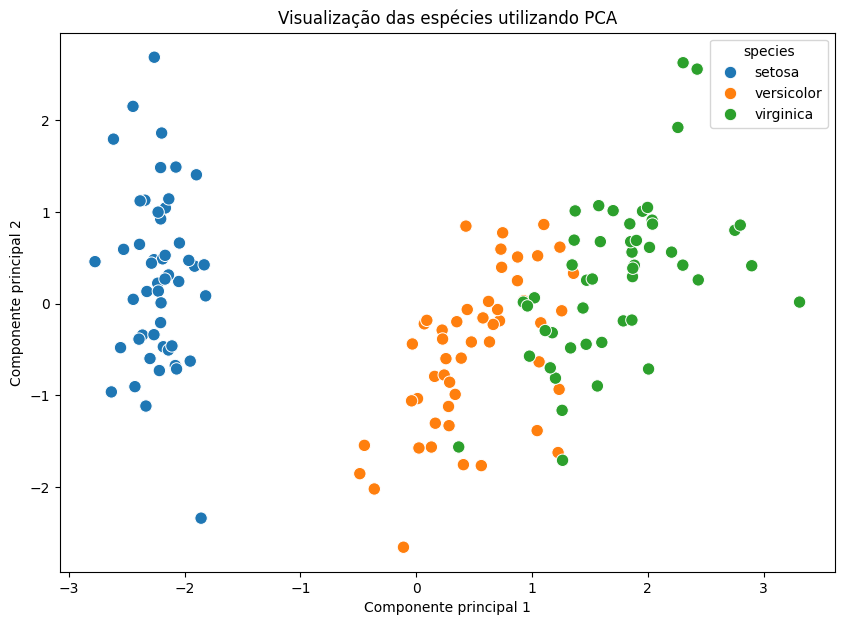

In [34]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    s=80
)

plt.title("Visualização das espécies utilizando PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

In [35]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

O PCA permitiu representar as quatro variáveis originais em apenas duas dimensões, preservando grande parte da variabilidade dos dados e facilitando a visualização da separação entre as espécies.

## Perguntas



*   Qual espécie é mais fácil de identificar?

    A setosa, porque suas pétalas são claramente menores.

*   Quais espécies são mais semelhantes?

    Versicolor e virginica, pois apresentam alguma sobreposição.

*   Quais variáveis diferenciam melhor as espécies?

    Comprimento e largura da pétala.

*   Quais variáveis diferenciam menos?

    As medidas das sépalas geralmente apresentam maior sobreposição.


*   O dataset está balanceado?

    Sim, as três espécies possuem a mesma quantidade de observações.

*   Existem dados ausentes?

    Não.

* Existem possíveis valores extremos?

    Podem existir valores identificados pelo método do intervalo interquartil, mas eles não devem ser removidos sem investigação.

A análise exploratória demonstrou que as três espécies do dataset Iris apresentam diferenças relevantes em suas características morfológicas. Entre as variáveis analisadas, o comprimento e a largura das pétalas foram as que proporcionaram melhor separação entre as espécies. A Setosa apresentou características claramente distintas, com pétalas menores e mais estreitas. A Versicolor ocupou uma região intermediária, enquanto a Virginica apresentou, em média, as maiores medidas de pétala.

As medidas das sépalas apresentaram maior sobreposição, especialmente entre Versicolor e Virginica, indicando menor capacidade de separação quando analisadas isoladamente. A matriz de correlação também revelou uma forte relação positiva entre o comprimento e a largura das pétalas. Portanto, os resultados indicam que as características das pétalas são as mais informativas para diferenciar as espécies presentes no dataset.